In [35]:
import tarfile
import os
import shutil
import scipy.io
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path
import time
import random



In [ ]:
import tarfile, os

tar_path = "102flowers.tar"
extract_path = "data"
os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_path, filter="data")

print("Extracted:", os.listdir(extract_path))


Extracted: ['flowers_custom', 'jpg', 'cnn_dataset']


In [ ]:

import scipy.io
mat = scipy.io.loadmat("imagelabels.mat") 
labels = mat['labels'][0] 


src_dir = "data/jpg"
out_dir = "flowers" 


for i in range(1, 103):  # 1-indexed class labels
    os.makedirs(os.path.join(out_dir, f"{i:03d}"), exist_ok=True)

for idx, label in tqdm(enumerate(labels), total=len(labels)):
    img_name = f"image_{idx+1:05d}.jpg"
    src_path = os.path.join(src_dir, img_name)
    dst_path = os.path.join(out_dir, f"{label:03d}", img_name)
    shutil.copy(src_path, dst_path)

print("Finished organizing into ImageFolder format!")


100%|██████████| 8189/8189 [00:02<00:00, 3179.79it/s]

Finished organizing into ImageFolder format!


In [ ]:
SRC = Path("data/jpg") 
OUT = Path("flowers")
SEED = 42
SPLIT = {"train": 0.80, "val": 0.10, "test": 0.10}  # must sum to 1.0


labels_np = np.asarray(labels, dtype=int)   
N = len(labels_np)
img_ids = np.arange(1, N + 1, dtype=int)      


rng = np.random.RandomState(SEED)
classes = np.unique(labels_np)

train_ids, val_ids, test_ids = [], [], []
for c in classes:
    idx_c = np.where(labels_np == c)[0]      
    ids_c = img_ids[idx_c] 
    n_c = len(ids_c)

    ids_c = ids_c.copy()
    rng.shuffle(ids_c)

    n_test = int(round(SPLIT["test"] * n_c))
    n_val  = int(round(SPLIT["val"]  * n_c))
    n_train = n_c - n_val - n_test

    # ensure train ≥ 1 per class
    if n_train < 1:
        deficit = 1 - n_train
        take_from_val = min(deficit, n_val); n_val -= take_from_val; deficit -= take_from_val
        if deficit > 0:
            take_from_test = min(deficit, n_test); n_test -= take_from_test; deficit -= take_from_test
        n_train = n_c - n_val - n_test

    #To keep val/test non-empty when possible
    if n_c >= 3:
        if n_val < 1:
            if n_train > 1: n_val += 1; n_train -= 1
            elif n_test > 1: n_val += 1; n_test -= 1
        if n_test < 1:
            if n_train > 1: n_test += 1; n_train -= 1
            elif n_val > 1: n_test += 1; n_val -= 1


    train_ids.extend(ids_c[:n_train])
    val_ids.extend(ids_c[n_train:n_train+n_val])
    test_ids.extend(ids_c[n_train+n_val:])

train_ids = np.array(train_ids, dtype=int)
val_ids   = np.array(val_ids,   dtype=int)
test_ids  = np.array(test_ids,  dtype=int)

def present_classes(ids):
    return set(labels_np[ids - 1])

all_classes = set(classes)


print(f"Final split sizes => train={len(train_ids)}  val={len(val_ids)}  test={len(test_ids)}")
print(f"Classes in train: {len(present_classes(train_ids))}/{len(all_classes)}")
print(f"Classes in val:   {len(present_classes(val_ids))}/{len(all_classes)}")
print(f"Classes in test:  {len(present_classes(test_ids))}/{len(all_classes)}")


for split in ["train", "val", "test"]:
    for cls in range(1, 103):
        (OUT / split / f"{cls:03d}").mkdir(parents=True, exist_ok=True)

def link_or_copy(src: Path, dst: Path):
    if dst.exists():
        return
    try:
        os.link(src, dst)
    except OSError:
        try:
            os.symlink(src, dst)
        except OSError:
            shutil.copy2(src, dst)

def place(ids: np.ndarray, split_name: str):
    for img_id in tqdm(ids, desc=f"Organizing {split_name}", unit="img"):
        img_name = f"image_{int(img_id):05d}.jpg"
        src_path = SRC / img_name
        if not src_path.exists():
            raise FileNotFoundError(f"Missing image: {src_path}")
        cls = int(labels_np[img_id - 1])  # 1-indexed
        dst_path = OUT / split_name / f"{cls:03d}" / img_name
        link_or_copy(src_path, dst_path)

place(train_ids, "train")
place(val_ids,   "val")
place(test_ids,  "test")

def count_jpgs(root: Path): return sum(1 for _ in root.rglob("*.jpg"))
print("Final counts:",
      "train=", count_jpgs(OUT/"train"),
      "val=",   count_jpgs(OUT/"val"),
      "test=",  count_jpgs(OUT/"test"))
print("Finished organizing into ImageFolder format with stratified splits.")


Final split sizes => train=6553  val=818  test=818
Classes in train: 102/102
Classes in val:   102/102
Classes in test:  102/102


Organizing test: 100%|██████████| 818/818 [00:00<00:00, 53306.93img/s]

Final counts: train= 6553 val= 818 test= 818
Finished organizing into ImageFolder format with stratified splits.


In [17]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, zero_init_last_bn=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

        if zero_init_last_bn:
            nn.init.constant_(self.bn2.weight, 0.0)  # improves optimization stability

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out = out + identity
        return self.relu(out)

class ResNet34(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, 7, 2, 3, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.relu  = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, 2, 1)

        self.layer1 = self._make_layer(64,  3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

        self._init_weights()  # <-- add init

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * BasicBlock.expansion, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion),
            )
        layers = [BasicBlock(self.in_channels, out_channels, stride, downsample, zero_init_last_bn=True)]
        self.in_channels = out_channels * BasicBlock.expansion
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels, 1, None, zero_init_last_bn=True))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

def resnet34(num_classes=102):
    return ResNet34(num_classes=num_classes)


In [ ]:
import os, platform, torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader


if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)


image_mean = [0.485, 0.456, 0.406]
image_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(image_mean, image_std),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(image_mean, image_std),
])


data_root = "flowers"
train_ds = datasets.ImageFolder(os.path.join(data_root, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(data_root, "val"),   transform=eval_tf)
test_dir = os.path.join(data_root, "test")
test_ds  = datasets.ImageFolder(test_dir, transform=eval_tf) if os.path.isdir(test_dir) else val_ds

num_classes = len(train_ds.classes)
print("Classes:", num_classes)


BATCH_SIZE  = 32 
NUM_WORKERS = 0
PIN_MEMORY  = (DEVICE.type == "cuda")

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
train_loader = DataLoader(train_ds, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_ds,  shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds, shuffle=False, **loader_kw)


Device: mps
Classes: 102


In [ ]:

model = ResNet34(num_classes=num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
EPOCHS = 100
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# AMP only on CUDA
use_amp = (DEVICE.type == "cuda")
if use_amp:
    from torch.cuda.amp import autocast, GradScaler
    scaler = GradScaler(enabled=True)
else:
    from contextlib import contextmanager
    @contextmanager
    def autocast(enabled=False): yield
    class _NoScaler:
        def scale(self, x): return x
        def step(self, opt): opt.step()
        def update(self): pass
        def unscale_(self, opt): pass
    scaler = _NoScaler()

def accuracy(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    all_preds, all_tgts = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = model(xb)
        loss = criterion(out, yb)
        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy(out, yb) * bs
        n += bs
        all_preds.append(out.argmax(1).cpu())
        all_tgts.append(yb.cpu())
    return total_loss / n, total_acc / n, torch.cat(all_preds).numpy(), torch.cat(all_tgts).numpy()

def train_one_epoch(model, loader, optimizer, criterion, scaler, grad_clip=1.0):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=use_amp):
            out = model(xb)
            loss = criterion(out, yb)
        scaler.scale(loss).backward()
        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer); scaler.update()
        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy(out.detach(), yb) * bs
        n += bs
    return total_loss / n, total_acc / n


best_val_acc, wait, patience = 0.0, 0, 15
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
best_path = "resnet34_flowers_best.pth"
start = time.time()

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={va_loss:.4f} acc={va_acc:.4f} | "
          f"lr={scheduler.get_last_lr()[0]:.5f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), best_path)
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}. Best val acc: {best_val_acc:.4f}")
            break

print(f"Training done Best val acc: {best_val_acc:.4f}  (time ~{(time.time()-start)/60:.1f} min)")
print(f"Saved best weights to: {best_path}")


Epoch 001/100 | train_loss=4.4823 acc=0.0418 | val_loss=4.3494 acc=0.0562 | lr=0.09998
Epoch 002/100 | train_loss=4.1496 acc=0.0729 | val_loss=3.8879 acc=0.1088 | lr=0.09990
Epoch 003/100 | train_loss=4.0142 acc=0.0934 | val_loss=3.9270 acc=0.1186 | lr=0.09978
Epoch 004/100 | train_loss=3.9209 acc=0.1134 | val_loss=3.6280 acc=0.1504 | lr=0.09961
Epoch 005/100 | train_loss=3.7938 acc=0.1279 | val_loss=3.4665 acc=0.1932 | lr=0.09938
Epoch 006/100 | train_loss=3.6914 acc=0.1543 | val_loss=3.3800 acc=0.2188 | lr=0.09911
Epoch 007/100 | train_loss=3.5923 acc=0.1761 | val_loss=3.1996 acc=0.2873 | lr=0.09880
Epoch 008/100 | train_loss=3.5091 acc=0.1901 | val_loss=3.4016 acc=0.2543 | lr=0.09843
Epoch 009/100 | train_loss=3.4042 acc=0.2222 | val_loss=3.4526 acc=0.2714 | lr=0.09801
Epoch 010/100 | train_loss=3.2848 acc=0.2498 | val_loss=2.8258 acc=0.3863 | lr=0.09755
Epoch 011/100 | train_loss=3.1650 acc=0.2849 | val_loss=2.7051 acc=0.4279 | lr=0.09704
Epoch 012/100 | train_loss=3.0493 acc=0.316

## Visualizations:


TEST  loss=1.0738  acc=0.9303


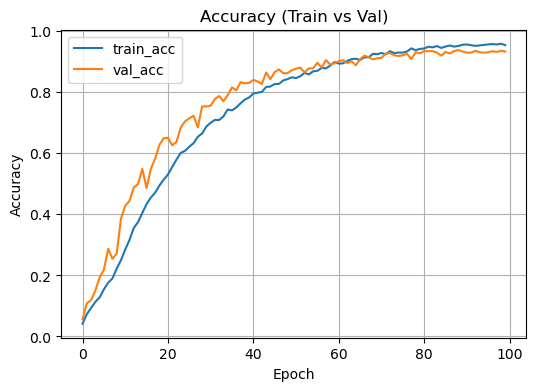

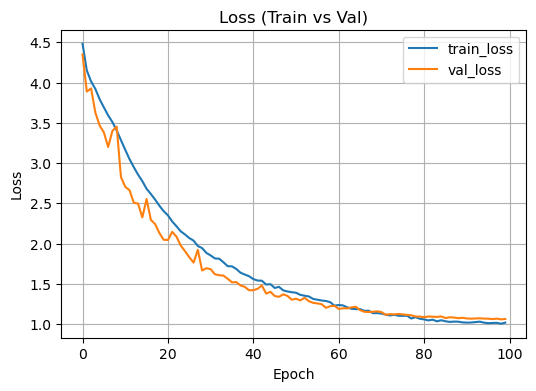

              precision    recall  f1-score   support

         001       0.80      1.00      0.89         4
         002       1.00      1.00      1.00         6
         003       0.50      0.75      0.60         4
         004       1.00      0.50      0.67         6
         005       1.00      0.67      0.80         6
         006       0.75      0.75      0.75         4
         007       0.80      1.00      0.89         4
         008       1.00      1.00      1.00         8
         009       1.00      1.00      1.00         5
         010       0.80      1.00      0.89         4
         011       0.80      0.89      0.84         9
         012       0.82      1.00      0.90         9
         013       1.00      0.80      0.89         5
         014       0.83      1.00      0.91         5
         015       1.00      1.00      1.00         5
         016       1.00      0.75      0.86         4
         017       1.00      1.00      1.00         8
         018       0.89    

In [33]:
# --- Load best & evaluate on test ---


model.load_state_dict(torch.load(best_path, map_location=DEVICE))
test_loss, test_acc, test_preds, test_tgts = evaluate(model, test_loader, criterion)
print(f"TEST  loss={test_loss:.4f}  acc={test_acc:.4f}")


plt.figure(figsize=(6,4))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"],   label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy (Train vs Val)")
plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"],   label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss (Train vs Val)")
plt.legend(); plt.grid(True); plt.show()


# Classification report
print(classification_report(test_tgts, test_preds, target_names=train_ds.classes))


In [34]:
pos_class = 0
y_true_bin = (np.array(test_tgts) == pos_class).astype(int)
y_pred_bin = (np.array(test_preds) == pos_class).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()

print(f"True Positives:  {tp}")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")


True Positives:  4
True Negatives:  813
False Positives: 1
False Negatives: 0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.42692].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8550389].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.622571].


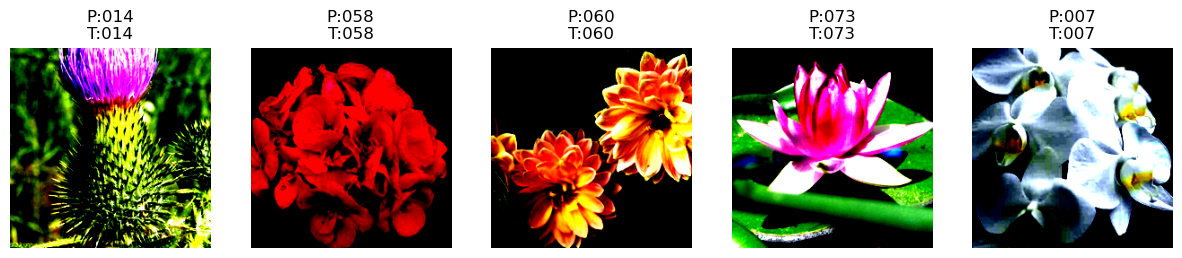

In [ ]:
idxs = random.sample(range(len(test_tgts)), 5)
model.eval()

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, idx in zip(axes, idxs):
    img, label = test_loader.dataset[idx]
    ax.imshow(np.transpose(img.numpy(), (1,2,0)))
    ax.axis('off')
    ax.set_title(f"P:{train_ds.classes[test_preds[idx]]}\nT:{train_ds.classes[test_tgts[idx]]}")
plt.show()


## Extracting Feature Maps from Selected Layers Using Forward Hooks

In [23]:
import torch
import matplotlib.pyplot as plt

# Choose layers to inspect (early, mid, late)
layers_to_hook = [model.layer1[0].conv1,   # early
                  model.layer2[1].conv2,   # middle
                  model.layer4[1].conv2]   # late

# Dictionary to store outputs
feature_maps = {}

def hook_fn(module, input, output):
    feature_maps[module] = output.detach().cpu()

# Register hooks
hooks = []
for layer in layers_to_hook:
    hooks.append(layer.register_forward_hook(hook_fn))


In [24]:
model.eval()
sample_img, _ = next(iter(test_loader))
sample_img = sample_img[:1].to(DEVICE)

with torch.no_grad():
    _ = model(sample_img)


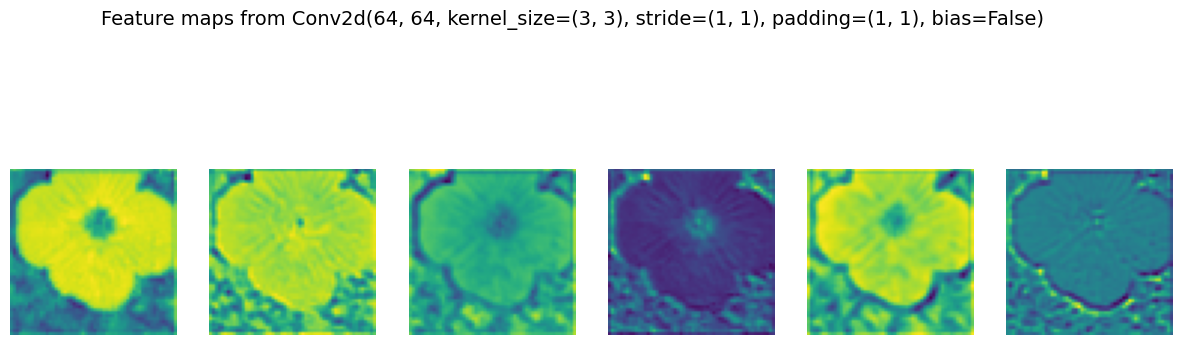

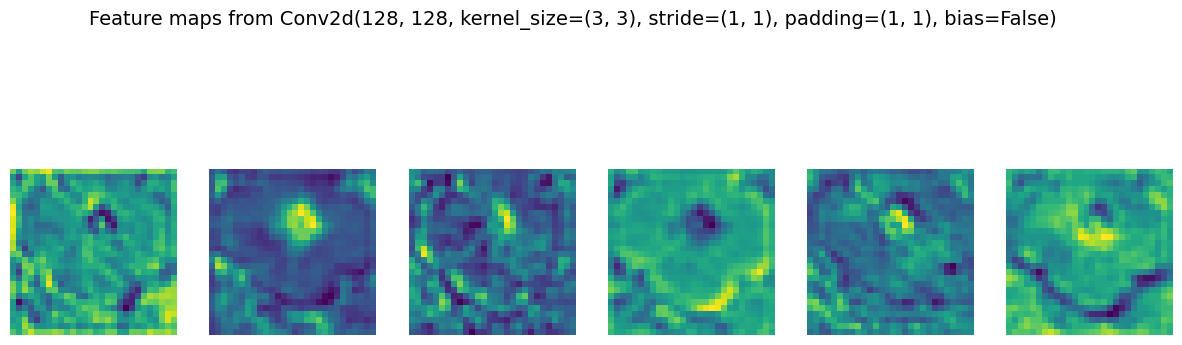

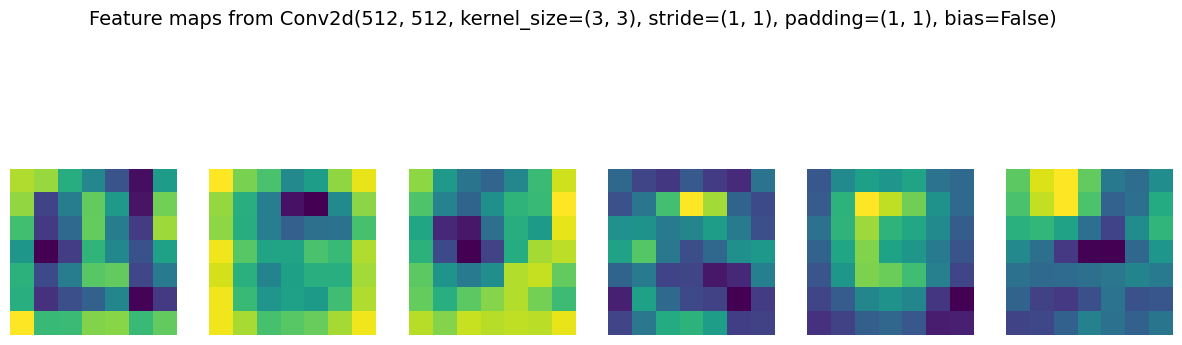

In [ ]:
def show_feature_maps(layer_output, layer_name, n_features=6):
    fmap = layer_output.squeeze(0)  # remove batch dim
    n_feat = min(n_features, fmap.size(0))
    fig, axes = plt.subplots(1, n_feat, figsize=(15, 5))
    for i in range(n_feat):
        axes[i].imshow(fmap[i].numpy(), cmap='viridis')
        axes[i].axis('off')
    fig.suptitle(f"Feature maps from {layer_name}", fontsize=14)
    plt.show()

for layer in feature_maps:
    show_feature_maps(feature_maps[layer], str(layer))


Early layer (Conv2d(64,64)) → clearly preserves the flower’s texture and edges — detecting color gradients and contours.

Middle layer (Conv2d(128,128)) → responds to petal shapes, centers, and repeated motifs, more pattern-oriented than pixel-level.

Late layer (Conv2d(512,512)) → becomes highly abstract and spatially compressed, focusing on discriminative semantic blobs rather than edges.

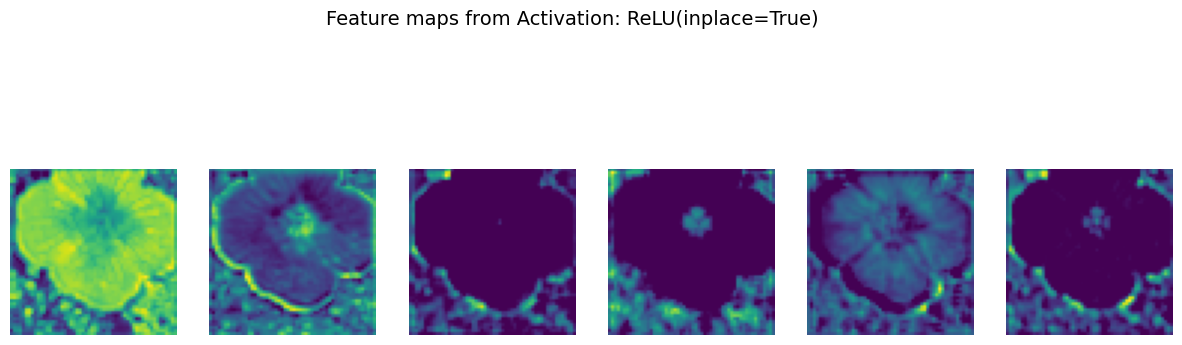

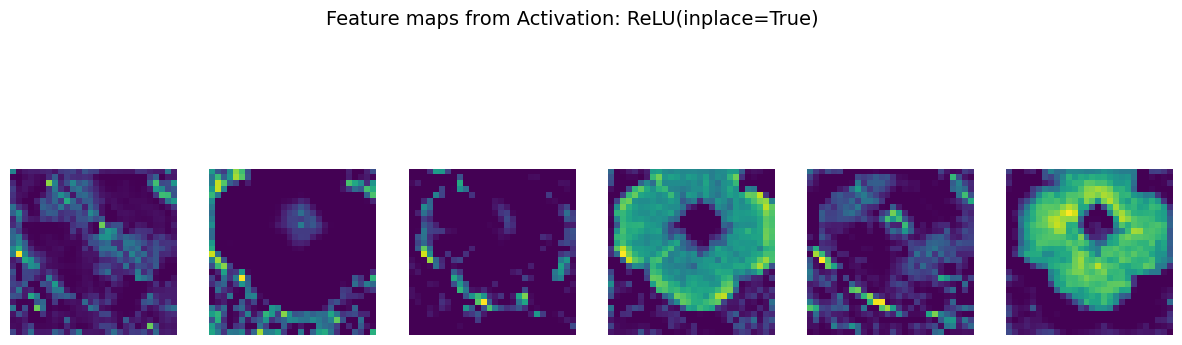

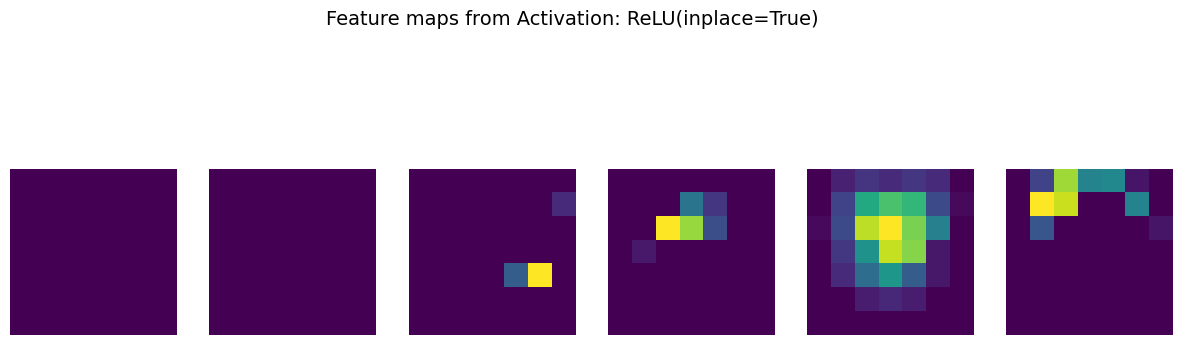

In [26]:
act_maps = {}
relu_layers = [model.layer1[0].relu, model.layer2[1].relu, model.layer4[1].relu]

def act_hook_fn(module, input, output):
    act_maps[module] = output.detach().cpu()

act_hooks = []
for layer in relu_layers:
    act_hooks.append(layer.register_forward_hook(act_hook_fn))

# Forward pass again
with torch.no_grad():
    _ = model(sample_img)

# Visualize one example layer
for layer in act_maps:
    show_feature_maps(act_maps[layer], f"Activation: {layer}")


🧠 Overview

The activation maps display what different layers of ResNet-34 focus on after applying ReLU.
Each layer progressively learns more abstract and meaningful features from the input image.

🟢 Early Activation (Shallow Layer)

The flower’s shape and edges are still visible.

Some regions are completely dark — meaning ReLU has suppressed negative activations.

The layer is focusing on basic edges, colors, and texture patterns.

➤ Interpretation

The early convolution layers detect low-level features such as edges, gradients, and simple textures.

🟡 Middle Activation (Intermediate Layer)

Only parts of the flower (like the center and petal texture) remain active.

The background and irrelevant details are mostly gone.

Feature maps appear more structured and selective.

➤ Interpretation

Intermediate layers represent part-based features, combining low-level patterns into meaningful regions (petals, centers, etc.).

🔴 Deep Activation (Final Layer)

The activations are very sparse and abstract.

Only small regions show strong responses.

The original image structure is mostly lost, replaced by semantic feature blobs.

➤ Interpretation

Deep layers encode high-level concepts, focusing on the most discriminative regions that define the object class.

🧩 Key Takeaways

ReLU creates sparsity by keeping only positive activations.

Feature abstraction increases with layer depth — from textures → shapes → semantic concepts.

Spatial detail decreases, but semantic meaning increases.

The model progressively learns what matters most for classification.

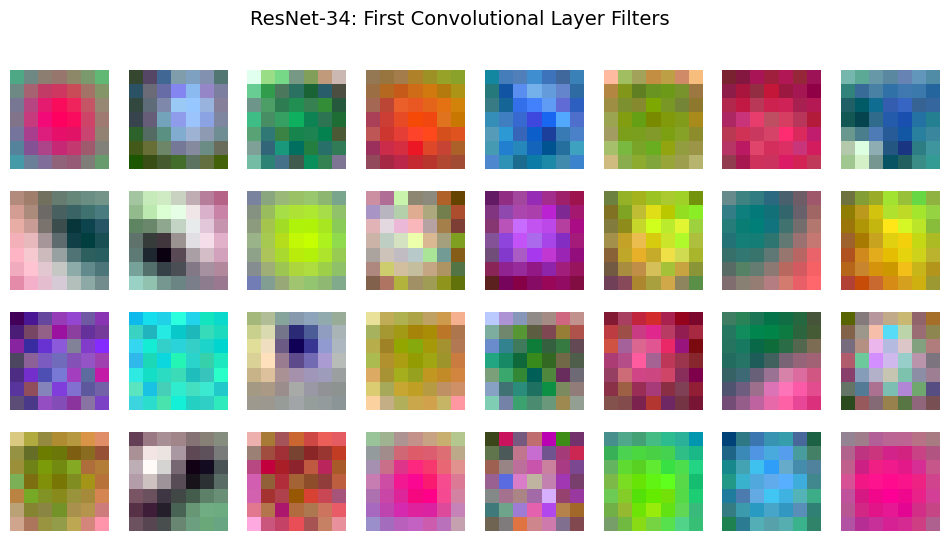

In [27]:
weights = model.conv1.weight.data.cpu()

fig, axes = plt.subplots(4, 8, figsize=(12,6))
for i, ax in enumerate(axes.flat):
    if i < weights.size(0):
        w = weights[i]
        w = (w - w.min()) / (w.max() - w.min())  # normalize to [0,1]
        ax.imshow(np.transpose(w.numpy(), (1,2,0)))
        ax.axis('off')
plt.suptitle("ResNet-34: First Convolutional Layer Filters", fontsize=14)
plt.show()


🧠 Overview

The first layer of ResNet-34 learns simple visual features like edges, colors, and textures.

🔹 Observations

Filters capture color gradients and edge directions.

Some respond to specific hues or brightness changes.

They resemble Gabor-like filters from classical vision.

🔹 Interpretation

These filters detect low-level patterns that form the base for deeper layers to recognize complex shapes.

🔹 Key Point

Early layers focus on edges and color contrasts, while later layers build on these to identify object-level features.